# Ablation Study — FaceGroundVLM

Análise completa do grid de ablação **G1–G6**, comparação com benchmarks
publicados (BLIP, BLIP-TI, RECCE-BLIP-TI, TruthLens) e visualizações
avançadas (localização, t-SNE, GradCAM).

| Seção | Conteúdo |
|-------|----------|
| **S1** | Setup e carregamento |
| **S2** | Tabela comparativa do ablation |
| **S3** | Análise por método de manipulação |
| **S4** | Métricas de localização (G4 / G6) |
| **S5** | Amostras visuais com bounding boxes |
| **S6** | Comparação com benchmarks publicados |
| **S7** | Placeholder: t-SNE do DINOv2 LoRA classifier |
| **S8** | Placeholder: GradCAM / Attention Maps do DINOv2 |
| **S9** | Coerência veredito × justificativa |
| **S10** | Exportação de resumos (CSV) |

---
## S1. Setup e Carregamento

In [1]:
from __future__ import annotations

import json
import re
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from PIL import Image

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", font_scale=1.1)
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

In [2]:
ROOT = Path(".").resolve().parent
OUTPUTS = ROOT / "outputs" / "ablation"
FRAMES_DIR = ROOT / "ddvqa" / "frames"

EXPERIMENTS = {
    "G1 – Baseline (SigLIP)": {
        "dir": "g1_baseline",
        "eval_prefix": "s2_",
        "description": "SigLIP only, sem DINOv2",
        "components": {"SigLIP": True, "DINOv2": False, "LoRA DINOv2": False, "Loc": False, "Classifier": False},
    },
    "G2 – I-MoF (SigLIP+DINO)": {
        "dir": "g2_imof",
        "eval_prefix": "s2_",
        "description": "SigLIP + DINOv2 frozen (I-MoF)",
        "components": {"SigLIP": True, "DINOv2": True, "LoRA DINOv2": False, "Loc": False, "Classifier": False},
    },
    "G3 – DINOv2 LoRA": {
        "dir": "g3_lora",
        "eval_prefix": "",
        "description": "SigLIP + DINOv2 LoRA (deepfake-aware)",
        "components": {"SigLIP": True, "DINOv2": True, "LoRA DINOv2": True, "Loc": False, "Classifier": False},
    },
    "G4 – LoRA + Loc": {
        "dir": "g4_lora_loc",
        "eval_prefix": "",
        "description": "G3 + localização (bounding boxes), veredito end-to-end",
        "components": {"SigLIP": True, "DINOv2": True, "LoRA DINOv2": True, "Loc": True, "Classifier": False},
    },
    "G5 – LoRA + Classifier": {
        "dir": "g5_classifier",
        "eval_prefix": "",
        "description": "G3 modelo + veredito via classificador DINOv2",
        "components": {"SigLIP": True, "DINOv2": True, "LoRA DINOv2": True, "Loc": False, "Classifier": True},
    },
    "G6 – Full (Loc + Classifier)": {
        "dir": "g6_full",
        "eval_prefix": "",
        "description": "G4 modelo + veredito via classificador DINOv2",
        "components": {"SigLIP": True, "DINOv2": True, "LoRA DINOv2": True, "Loc": True, "Classifier": True},
    },
}

BENCHMARKS = {
    "BLIP": {"accuracy": 0.8168, "bleu_4": 0.3569, "rouge_l": 0.5664, "cider": 1.8177},
    "BLIP-TI": {"accuracy": 0.8749, "bleu_4": 0.4075, "rouge_l": 0.6085, "cider": 2.0567},
    "RECCE-BLIP-TI": {"accuracy": 0.9208, "bleu_4": None, "rouge_l": None, "cider": None},
    "TruthLens (I-MoF)": {"accuracy": 0.9412, "bleu_4": 0.4304, "rouge_l": 0.6285, "cider": 2.6321},
}

METHODS_ORDER = ["Deepfakes", "Face2Face", "FaceSwap", "FaceShifter", "NeuralTextures", "Original"]

print(f"Project root : {ROOT}")
print(f"Outputs dir  : {OUTPUTS}")
print(f"Frames dir   : {FRAMES_DIR}  (exists: {FRAMES_DIR.exists()})")

Project root : /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigLlama
Outputs dir  : /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigLlama/outputs/ablation
Frames dir   : /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigLlama/ddvqa/frames  (exists: True)


In [3]:
def load_results(exp_dir: str, prefix: str, split: str = "best_test") -> dict | None:
    path = OUTPUTS / exp_dir / "evaluation" / f"{prefix}{split}" / "results.json"
    if path.exists():
        return json.loads(path.read_text())
    return None


def load_predictions(exp_dir: str, prefix: str, split: str = "best_test") -> pd.DataFrame | None:
    path = OUTPUTS / exp_dir / "evaluation" / f"{prefix}{split}" / "predictions.jsonl"
    if not path.exists():
        return None
    records = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
    return pd.DataFrame(records)


results_all = {}
preds_all = {}
for name, cfg in EXPERIMENTS.items():
    r = load_results(cfg["dir"], cfg["eval_prefix"])
    p = load_predictions(cfg["dir"], cfg["eval_prefix"])
    if r is None:
        print(f"⚠ {name}: results.json não encontrado")
    else:
        results_all[name] = r
    if p is not None:
        preds_all[name] = p

print(f"\nExperimentos carregados: {len(results_all)}/{len(EXPERIMENTS)}")
print(f"Predictions carregados: {len(preds_all)}/{len(EXPERIMENTS)}")


Experimentos carregados: 6/6
Predictions carregados: 6/6


---
## S2. Tabela Comparativa do Ablation (Resultados Gerais)

In [5]:
METRICS_DISPLAY = [
    ("accuracy", "Acc"),
    ("f1", "F1"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("bleu_4", "BLEU-4"),
    ("rouge_l", "ROUGE-L"),
    ("cider", "CIDEr"),
]

rows = []
for name, r in results_all.items():
    row = {"Experiment": name}
    for key, label in METRICS_DISPLAY:
        row[label] = r.get(key)
    row["Classifier"] = r.get("classifier_used", False)
    rows.append(row)

for bname, bvals in BENCHMARKS.items():
    row = {"Experiment": bname}
    for key, label in METRICS_DISPLAY:
        row[label] = bvals.get(key)
    row["Classifier"] = "–"
    rows.append(row)

df_summary = pd.DataFrame(rows).set_index("Experiment")

def highlight_best(s):
    if s.dtype == object or s.name == "Classifier":
        return ["" for _ in s]
    numeric = pd.to_numeric(s, errors="coerce")
    is_max = numeric == numeric.max()
    return ["font-weight: bold; background-color: #008000" if v else "" for v in is_max]

styled = (
    df_summary
    .style
    .apply(highlight_best, axis=0)
    .format("{:.4f}", subset=[c for c in df_summary.columns if c != "Classifier"], na_rep="–")
    .set_caption("Ablation Study — DD-VQA Test Set (best checkpoint)")
)
styled

,Acc,F1,Precision,Recall,BLEU-4,ROUGE-L,CIDEr,Classifier
Experiment,,,,,,,,
G1 – Baseline (SigLIP),0.6344,0.7176,0.8611,0.6151,0.2111,0.5442,1.9691,False
G2 – I-MoF (SigLIP+DINO),0.7007,0.7836,0.8628,0.7178,0.2161,0.5346,1.8960,False
G3 – DINOv2 LoRA,0.9495,0.9658,0.9894,0.9433,0.2603,0.5865,2.3401,False
G4 – LoRA + Loc,0.9424,0.9606,0.9935,0.9298,0.2276,0.4979,0.9874,False
G5 – LoRA + Classifier,0.8960,0.9311,0.9317,0.9305,0.2539,0.5769,2.2099,True
G6 – Full (Loc + Classifier),0.8960,0.9311,0.9317,0.9305,0.2233,0.4908,0.9352,True
BLIP,0.8168,–,–,–,0.3569,0.5664,1.8177,–
BLIP-TI,0.8749,–,–,–,0.4075,0.6085,2.0567,–
RECCE-BLIP-TI,0.9208,–,–,–,–,–,–,–


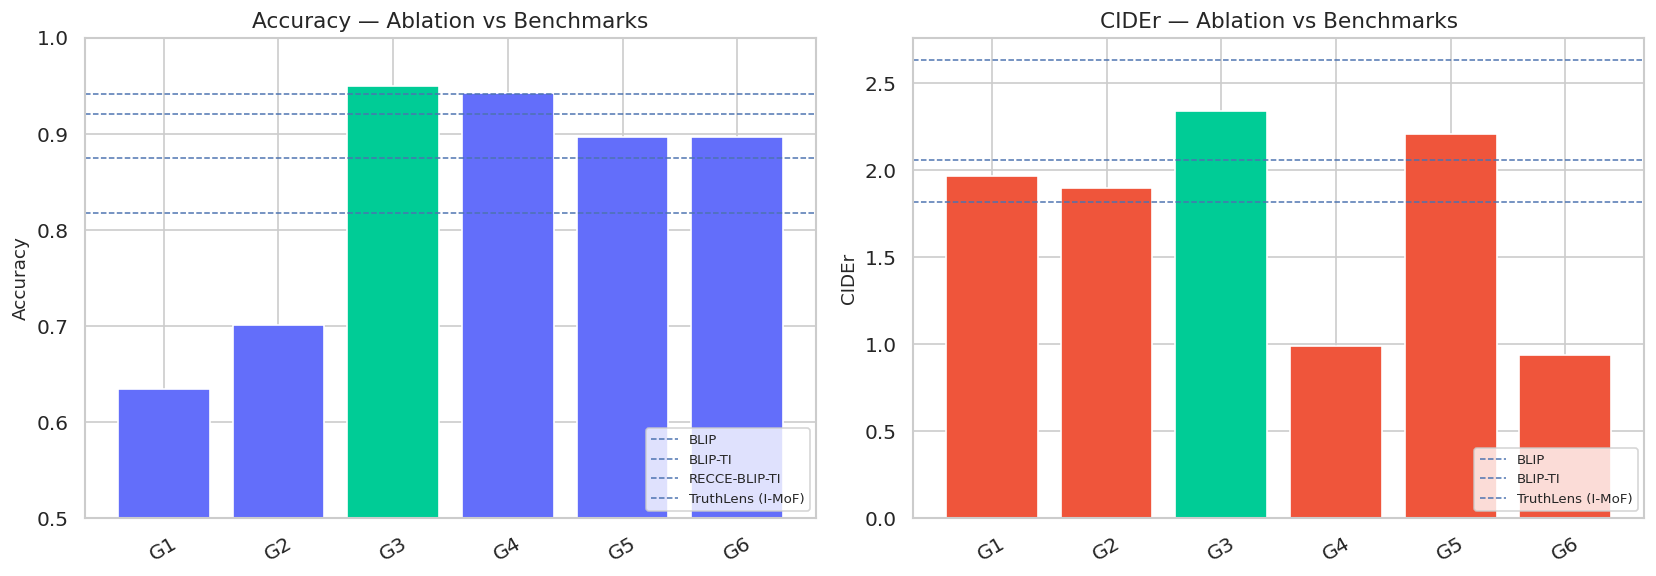

In [6]:
ablation_names = list(results_all.keys())
accs = [results_all[n]["accuracy"] for n in ablation_names]
ciders = [results_all[n]["cider"] for n in ablation_names]
short_names = [n.split(" – ")[0] for n in ablation_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#636efa"] * len(ablation_names)
best_acc_idx = int(np.argmax(accs))
colors[best_acc_idx] = "#00cc96"

axes[0].bar(short_names, accs, color=colors, edgecolor="white")
for bname, bvals in BENCHMARKS.items():
    if bvals["accuracy"] is not None:
        axes[0].axhline(bvals["accuracy"], ls="--", lw=0.9, label=bname)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy — Ablation vs Benchmarks")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].set_ylim(0.5, 1.0)
axes[0].tick_params(axis="x", rotation=30)

colors_c = ["#ef553b"] * len(ablation_names)
best_cid_idx = int(np.argmax(ciders))
colors_c[best_cid_idx] = "#00cc96"

axes[1].bar(short_names, ciders, color=colors_c, edgecolor="white")
for bname, bvals in BENCHMARKS.items():
    if bvals.get("cider") is not None:
        axes[1].axhline(bvals["cider"], ls="--", lw=0.9, label=bname)
axes[1].set_ylabel("CIDEr")
axes[1].set_title("CIDEr — Ablation vs Benchmarks")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(ROOT / "outputs" / "ablation" / "ablation_acc_cider.png", bbox_inches="tight")
plt.show()

### Componentes ativados por experimento

In [7]:
comp_rows = []
for name, cfg in EXPERIMENTS.items():
    row = {"Experiment": name.split(" – ")[0]}
    for comp, val in cfg["components"].items():
        row[comp] = "✓" if val else "–"
    if name in results_all:
        row["Acc"] = f"{results_all[name]['accuracy']:.2%}"
    comp_rows.append(row)

df_components = pd.DataFrame(comp_rows).set_index("Experiment")
df_components

,SigLIP,DINOv2,LoRA DINOv2,Loc,Classifier,Acc
Experiment,,,,,,
G1,✓,–,–,–,–,63.44%
G2,✓,✓,–,–,–,70.07%
G3,✓,✓,✓,–,–,94.95%
G4,✓,✓,✓,✓,–,94.24%
G5,✓,✓,✓,–,✓,89.60%
G6,✓,✓,✓,✓,✓,89.60%


---
## S3. Análise por Método de Manipulação

In [8]:
def per_method_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Compute accuracy and recall(fake) per manipulation method."""
    if "method" not in df.columns:
        return pd.DataFrame()
    rows = []
    for method in METHODS_ORDER:
        sub = df[df["method"] == method]
        if len(sub) == 0:
            continue
        total = len(sub)
        correct = sub["correct"].sum()
        acc = correct / total

        fake_sub = sub[sub["true_label"] == "fake"]
        recall_fake = (fake_sub["pred_label"] == "fake").mean() if len(fake_sub) > 0 else None

        real_sub = sub[sub["true_label"] == "real"]
        specificity = (real_sub["pred_label"] == "real").mean() if len(real_sub) > 0 else None

        rows.append({
            "Method": method,
            "N": total,
            "Accuracy": acc,
            "Recall (Fake)": recall_fake,
            "Specificity (Real)": specificity,
        })
    return pd.DataFrame(rows).set_index("Method")

In [9]:
experiments_to_compare = ["G1 – Baseline (SigLIP)", "G3 – DINOv2 LoRA", "G4 – LoRA + Loc"]

per_method_dfs = {}
for exp_name in experiments_to_compare:
    if exp_name in preds_all:
        per_method_dfs[exp_name] = per_method_metrics(preds_all[exp_name])

if per_method_dfs:
    acc_combined = pd.DataFrame({
        name.split(" – ")[0]: df["Accuracy"]
        for name, df in per_method_dfs.items()
    })
    recall_combined = pd.DataFrame({
        name.split(" – ")[0]: df["Recall (Fake)"]
        for name, df in per_method_dfs.items()
    })

    print("=== Accuracy por Método ===")
    display(acc_combined.style.format("{:.2%}", na_rep="–").set_caption("Accuracy por Método de Manipulação"))

    print("\n=== Recall (Fake) por Método ===")
    display(recall_combined.style.format("{:.2%}", na_rep="–").set_caption("Recall (Fake) por Método"))

=== Accuracy por Método ===


,G1,G3,G4
Method,,,
Deepfakes,84.86%,98.08%,97.84%
Face2Face,38.81%,91.50%,92.07%
FaceSwap,61.00%,91.33%,90.00%
FaceShifter,47.78%,99.44%,98.33%
NeuralTextures,65.52%,91.81%,85.34%
Original,69.38%,96.88%,98.12%



=== Recall (Fake) por Método ===


,G1,G3,G4
Method,,,
Deepfakes,84.86%,98.08%,97.84%
Face2Face,38.81%,91.50%,92.07%
FaceSwap,61.00%,91.33%,90.00%
FaceShifter,47.78%,99.44%,98.33%
NeuralTextures,65.52%,91.81%,85.34%
Original,–,–,–


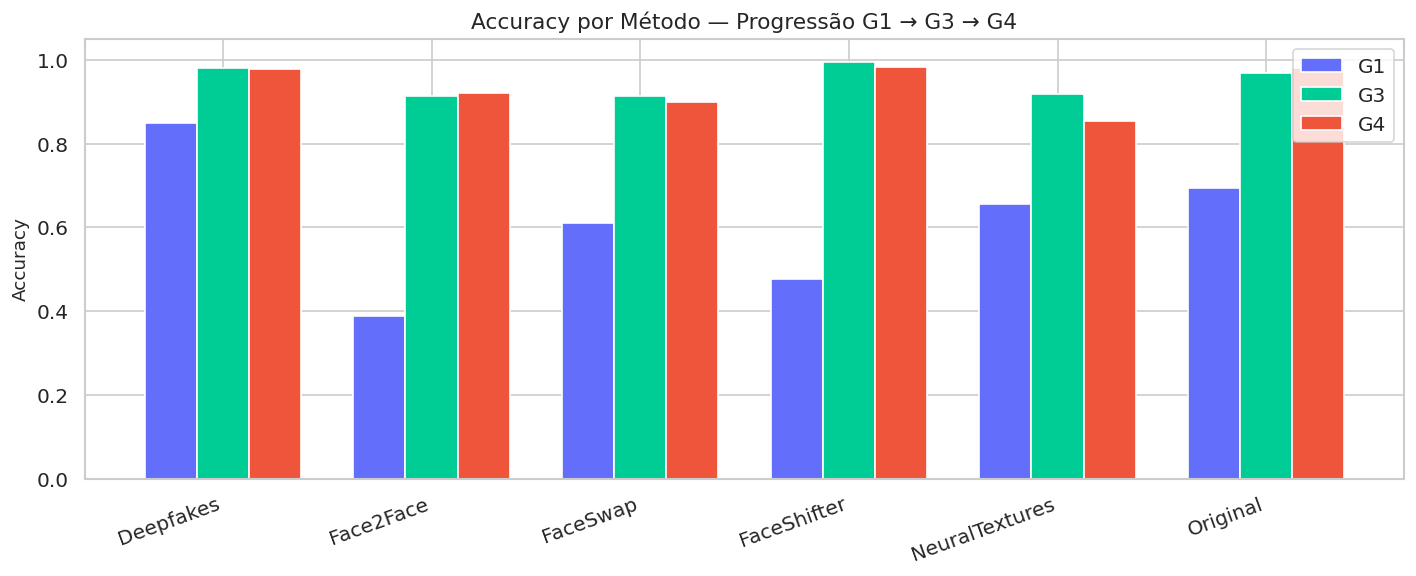

In [10]:
if per_method_dfs:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(METHODS_ORDER))
    width = 0.25
    palette = ["#636efa", "#00cc96", "#ef553b"]

    for i, (exp_name, df) in enumerate(per_method_dfs.items()):
        vals = [df.loc[m, "Accuracy"] if m in df.index else 0 for m in METHODS_ORDER]
        ax.bar(x + i * width, vals, width, label=exp_name.split(" – ")[0], color=palette[i])

    ax.set_xticks(x + width)
    ax.set_xticklabels(METHODS_ORDER, rotation=20, ha="right")
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy por Método — Progressão G1 → G3 → G4")
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

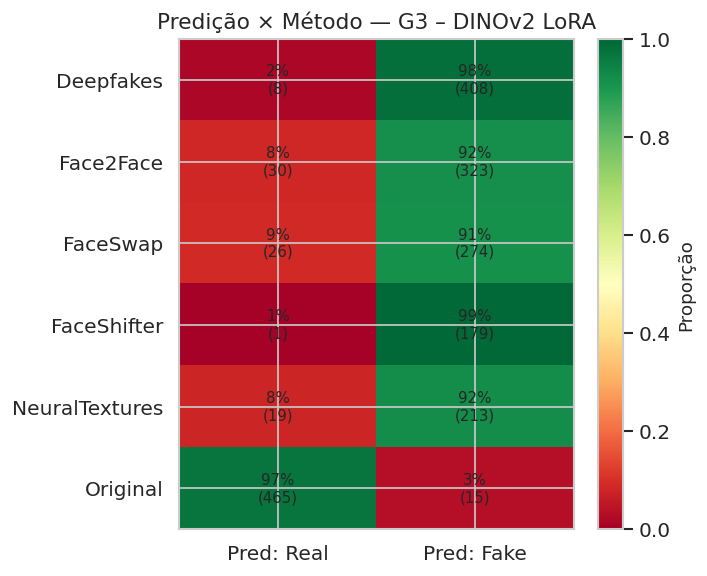

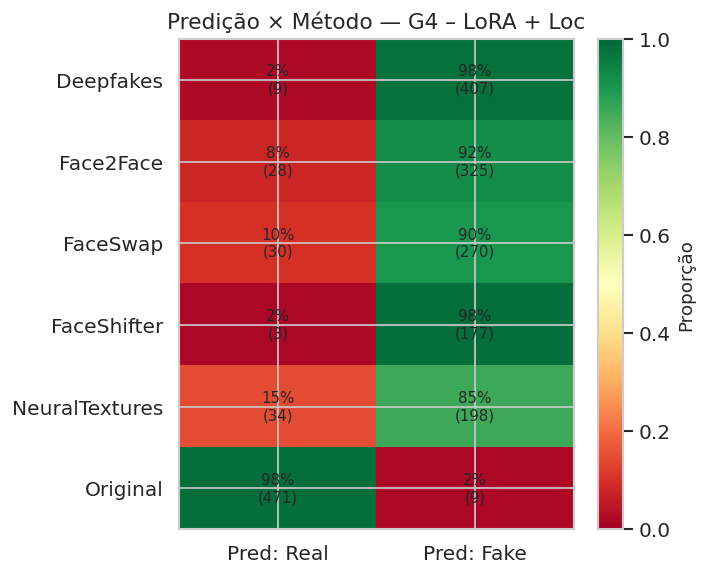

In [11]:
def confusion_by_method(df: pd.DataFrame, title: str = ""):
    """Plot a heatmap: predicted label (Real/Fake) vs manipulation method."""
    if "method" not in df.columns:
        print("Coluna 'method' não disponível")
        return
    pivot = pd.crosstab(df["method"], df["pred_label"])
    pivot = pivot.reindex(METHODS_ORDER, fill_value=0)
    for col in ["real", "fake"]:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot = pivot[["real", "fake"]]
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(pivot_pct.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pred: Real", "Pred: Fake"])
    ax.set_yticks(range(len(METHODS_ORDER)))
    ax.set_yticklabels(METHODS_ORDER)
    for i in range(pivot_pct.shape[0]):
        for j in range(pivot_pct.shape[1]):
            val = pivot_pct.values[i, j]
            count = pivot.values[i, j]
            ax.text(j, i, f"{val:.0%}\n({count})", ha="center", va="center", fontsize=9)
    plt.colorbar(im, ax=ax, label="Proporção")
    ax.set_title(title or "Pred × Method")
    plt.tight_layout()
    plt.show()


for exp_name in ["G3 – DINOv2 LoRA", "G4 – LoRA + Loc"]:
    if exp_name in preds_all:
        confusion_by_method(preds_all[exp_name], title=f"Predição × Método — {exp_name}")

---
## S4. Métricas de Localização (G4 e G6)

In [12]:
sys.path.insert(0, str(ROOT))
from evaluation.metrics import parse_loc_tokens, box_iou, compute_loc_metrics

In [13]:
loc_experiments = ["G4 – LoRA + Loc", "G6 – Full (Loc + Classifier)"]

loc_results = {}
for exp_name in loc_experiments:
    if exp_name not in preds_all:
        continue
    df = preds_all[exp_name]
    preds_text = df["generated"].tolist()
    refs_text = df["reference_answer"].tolist()
    metrics = compute_loc_metrics(preds_text, refs_text)
    loc_results[exp_name] = metrics

if loc_results:
    df_loc = pd.DataFrame(loc_results).T
    df_loc.columns = ["Mean IoU", "Hit Rate @0.3", "Total Ref Boxes"]
    display(df_loc.style.format({
        "Mean IoU": "{:.4f}",
        "Hit Rate @0.3": "{:.2%}",
        "Total Ref Boxes": "{:.0f}",
    }).set_caption("Métricas de Localização — DD-VQA Test"))

,Mean IoU,Hit Rate @0.3,Total Ref Boxes
G4 – LoRA + Loc,0.3797,62.03%,2141
G6 – Full (Loc + Classifier),0.3732,60.81%,2141


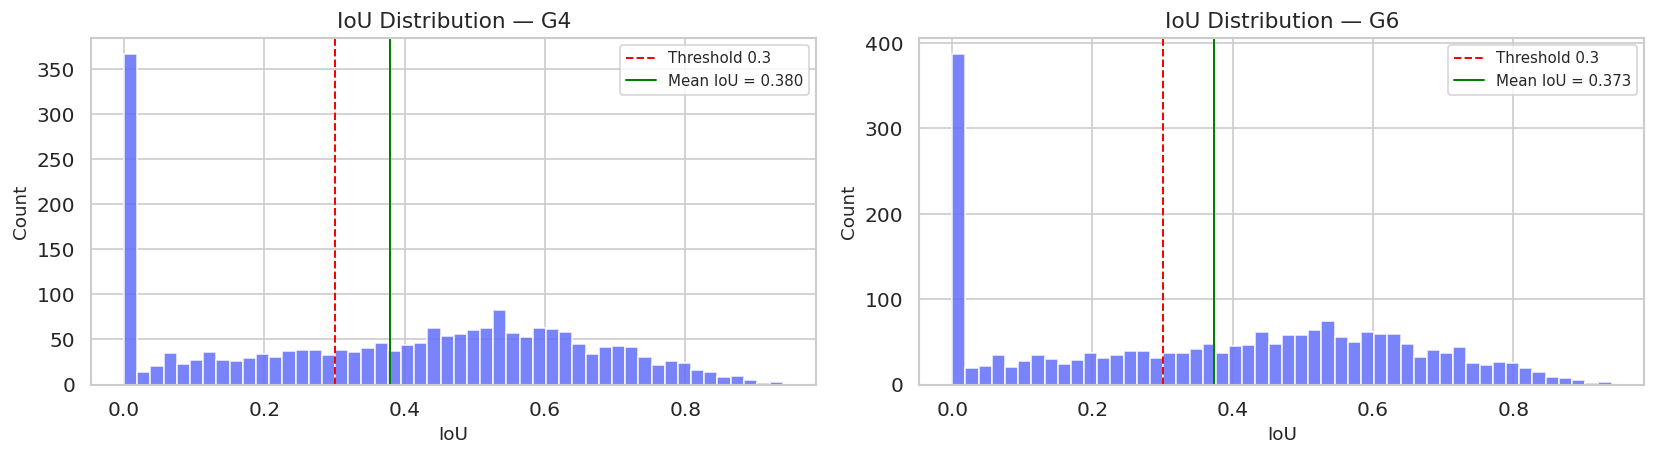

In [14]:
def compute_iou_distribution(df: pd.DataFrame) -> list[float]:
    """Return per-ref-box IoU values for histogram."""
    all_ious = []
    for _, row in df.iterrows():
        pred_boxes = parse_loc_tokens(row["generated"])
        ref_boxes = parse_loc_tokens(row["reference_answer"])
        if not ref_boxes:
            continue
        for rb in ref_boxes:
            if not pred_boxes:
                all_ious.append(0.0)
                continue
            best = max(box_iou(pb, rb) for pb in pred_boxes)
            all_ious.append(best)
    return all_ious


if loc_results:
    fig, axes = plt.subplots(1, len(loc_experiments), figsize=(7 * len(loc_experiments), 4), squeeze=False)
    for i, exp_name in enumerate(loc_experiments):
        if exp_name not in preds_all:
            continue
        ious = compute_iou_distribution(preds_all[exp_name])
        ax = axes[0, i]
        ax.hist(ious, bins=50, color="#636efa", edgecolor="white", alpha=0.85)
        ax.axvline(0.3, color="red", ls="--", lw=1.2, label="Threshold 0.3")
        mean_iou = np.mean(ious) if ious else 0
        ax.axvline(mean_iou, color="green", ls="-", lw=1.2, label=f"Mean IoU = {mean_iou:.3f}")
        ax.set_xlabel("IoU")
        ax.set_ylabel("Count")
        ax.set_title(f"IoU Distribution — {exp_name.split(' – ')[0]}")
        ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

---
## S5. Amostras Visuais com Localização

In [15]:
def draw_bboxes_on_image(
    img: Image.Image,
    pred_text: str,
    ref_text: str,
    ax: plt.Axes | None = None,
    title: str = "",
):
    """Draw predicted (red) and reference (green) bboxes on an image.

    Coordinates are in [0, 1000] normalized format (y1, x1, y2, x2).
    """
    w, h = img.size
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)

    pred_boxes = parse_loc_tokens(pred_text)
    ref_boxes = parse_loc_tokens(ref_text)

    for (y1, x1, y2, x2) in ref_boxes:
        rect = mpatches.Rectangle(
            (x1 / 1000 * w, y1 / 1000 * h),
            (x2 - x1) / 1000 * w,
            (y2 - y1) / 1000 * h,
            linewidth=2, edgecolor="lime", facecolor="none", linestyle="-",
        )
        ax.add_patch(rect)

    for (y1, x1, y2, x2) in pred_boxes:
        rect = mpatches.Rectangle(
            (x1 / 1000 * w, y1 / 1000 * h),
            (x2 - x1) / 1000 * w,
            (y2 - y1) / 1000 * h,
            linewidth=2, edgecolor="red", facecolor="none", linestyle="--",
        )
        ax.add_patch(rect)

    legend_patches = [
        mpatches.Patch(edgecolor="lime", facecolor="none", label="Ground Truth"),
        mpatches.Patch(edgecolor="red", facecolor="none", linestyle="--", label="Predicted"),
    ]
    ax.legend(handles=legend_patches, fontsize=8, loc="upper right")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

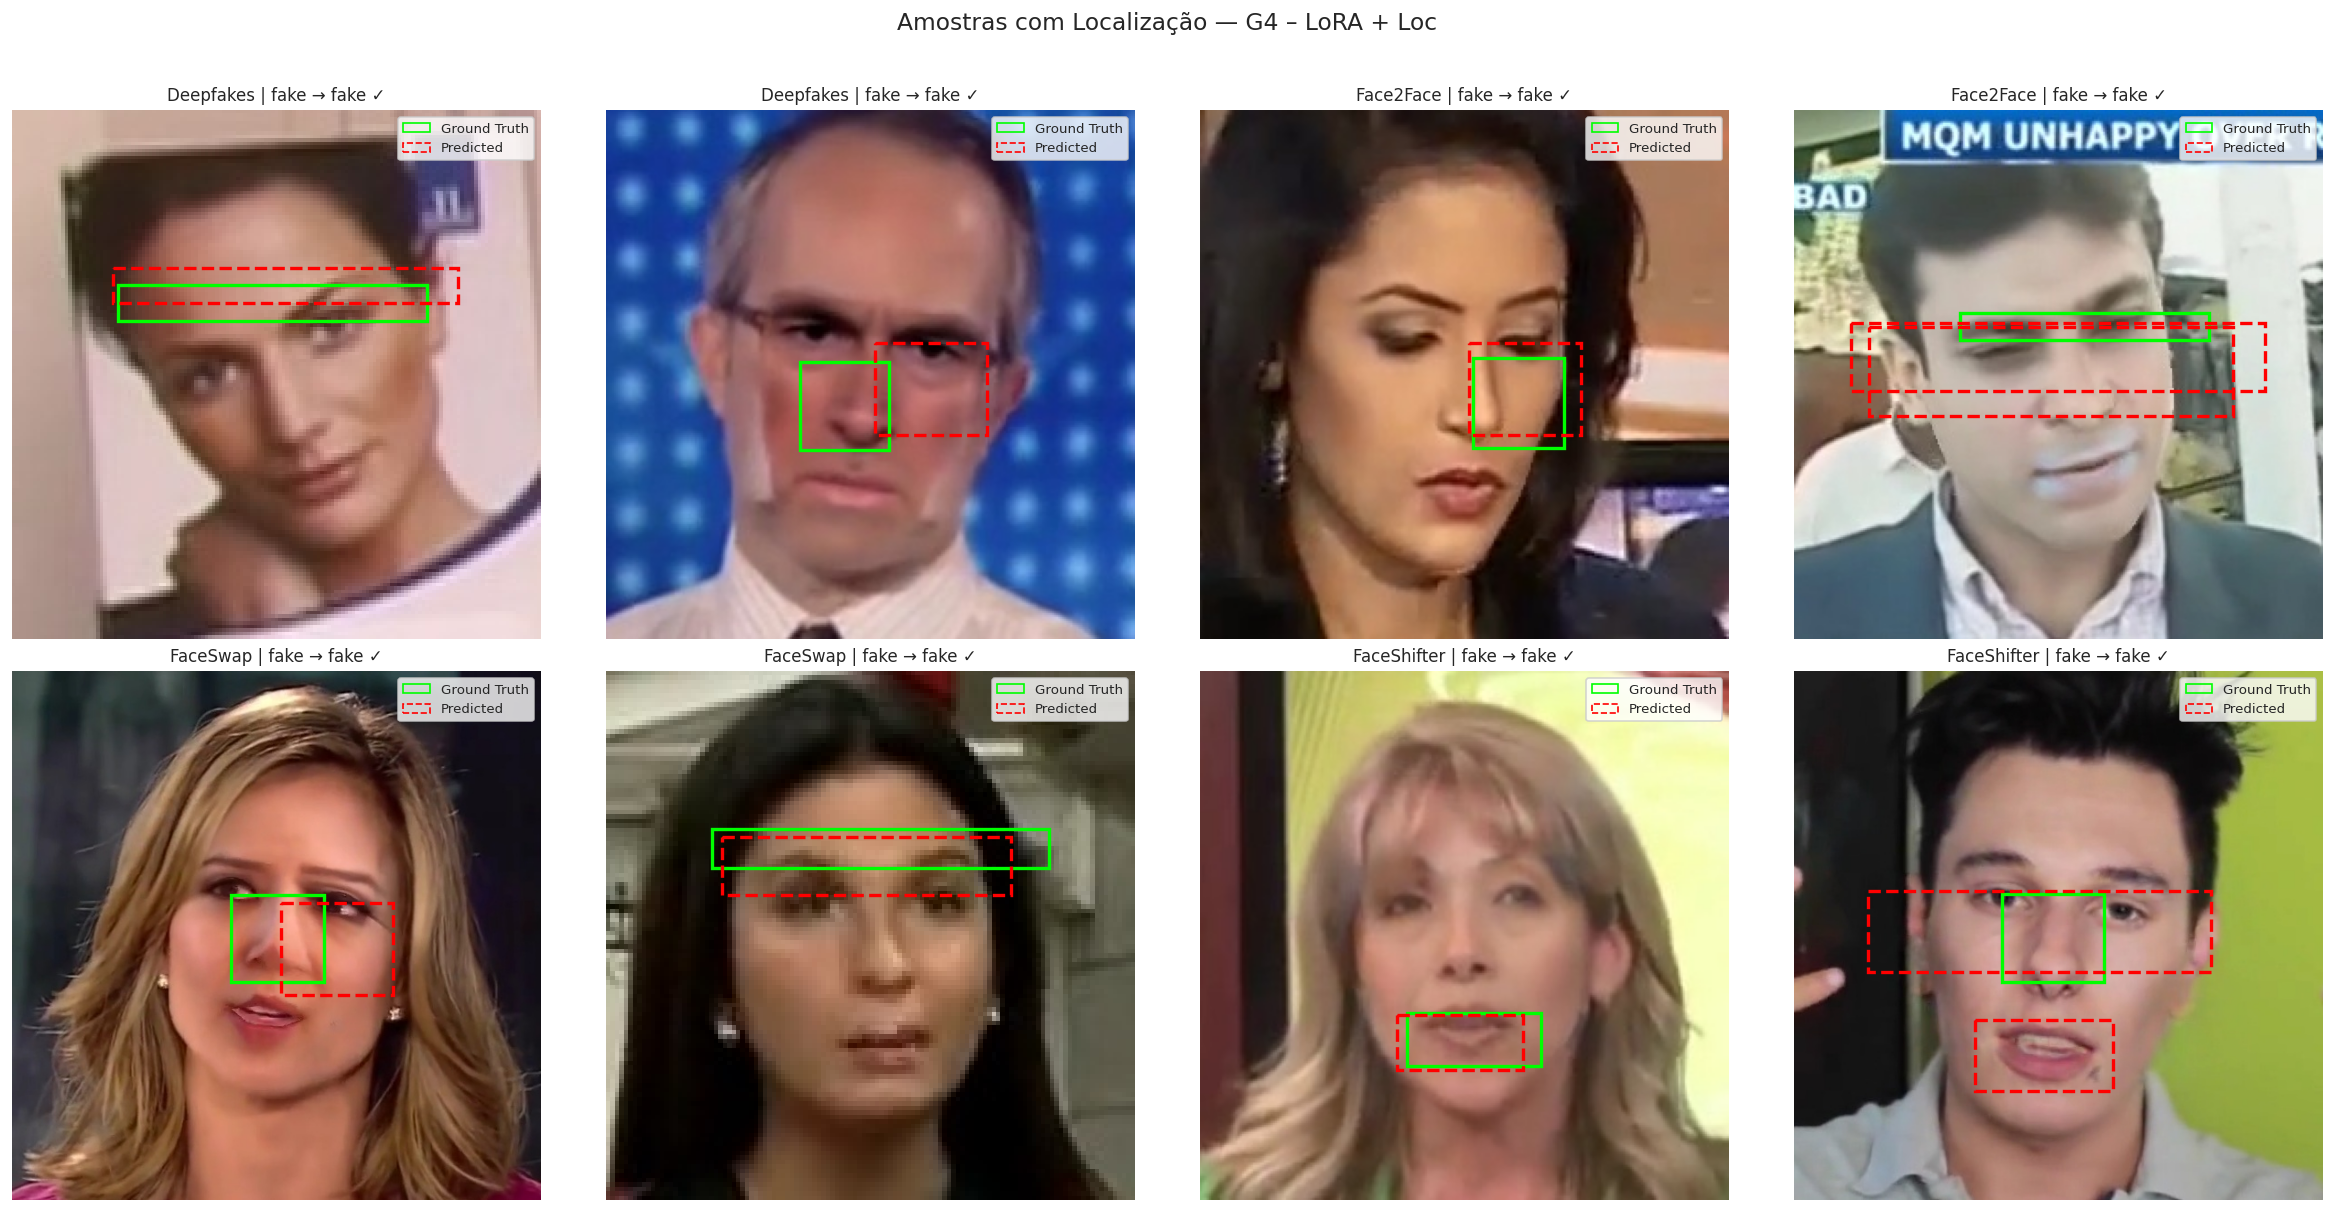

In [16]:
EXP_LOC = "G4 – LoRA + Loc"
N_SAMPLES = 8

if EXP_LOC in preds_all and FRAMES_DIR.exists():
    df_loc_pred = preds_all[EXP_LOC].copy()

    df_loc_pred["has_pred_bbox"] = df_loc_pred["generated"].apply(lambda t: len(parse_loc_tokens(t)) > 0)
    df_loc_pred["has_ref_bbox"] = df_loc_pred["reference_answer"].apply(lambda t: len(parse_loc_tokens(t)) > 0)

    df_with_bboxes = df_loc_pred[df_loc_pred["has_pred_bbox"] & df_loc_pred["has_ref_bbox"]]

    methods_available = df_with_bboxes["method"].unique()
    samples = []
    for method in METHODS_ORDER:
        if method in methods_available:
            method_df = df_with_bboxes[df_with_bboxes["method"] == method]
            n_pick = min(2, len(method_df))
            samples.append(method_df.sample(n=n_pick, random_state=42))
    if samples:
        sample_df = pd.concat(samples).head(N_SAMPLES)
    else:
        sample_df = df_with_bboxes.sample(n=min(N_SAMPLES, len(df_with_bboxes)), random_state=42)

    n_cols = 4
    n_rows = int(np.ceil(len(sample_df) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

    for idx, (_, row) in enumerate(sample_df.iterrows()):
        img_path = FRAMES_DIR / row["image"]
        if not img_path.exists():
            axes[idx].text(0.5, 0.5, f"Not found:\n{row['image']}", ha="center", transform=axes[idx].transAxes)
            continue
        img = Image.open(img_path).convert("RGB")
        verdict = "✓" if row["correct"] else "✗"
        title = f"{row['method']} | {row['true_label']} → {row['pred_label']} {verdict}"
        draw_bboxes_on_image(img, row["generated"], row["reference_answer"], ax=axes[idx], title=title)

    for idx in range(len(sample_df), len(axes)):
        axes[idx].axis("off")

    fig.suptitle(f"Amostras com Localização — {EXP_LOC}", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Predictions do G4 ou diretório de frames não disponíveis.")

In [17]:
if EXP_LOC in preds_all:
    df_show = preds_all[EXP_LOC]
    df_show_bbox = df_show[df_show["generated"].apply(lambda t: len(parse_loc_tokens(t)) > 0)]

    print(f"Total de amostras com bboxes preditas: {len(df_show_bbox)} / {len(df_show)} "
          f"({len(df_show_bbox)/len(df_show):.1%})")

    ref_bbox_count = df_show["reference_answer"].apply(lambda t: len(parse_loc_tokens(t)) > 0).sum()
    print(f"Total de amostras com bboxes na referência: {ref_bbox_count} / {len(df_show)} "
          f"({ref_bbox_count/len(df_show):.1%})")

    print("\n--- Exemplos de texto gerado com bboxes ---")
    for _, row in df_show_bbox.head(3).iterrows():
        print(f"\n[{row['method']}] {row['image']}")
        print(f"  Q: {row['question']}")
        print(f"  Gen: {row['generated'][:200]}")
        print(f"  Ref: {row['reference_answer'][:200]}")

Total de amostras com bboxes preditas: 1620 / 1961 (82.6%)
Total de amostras com bboxes na referência: 1610 / 1961 (82.1%)

--- Exemplos de texto gerado com bboxes ---

[Deepfakes] Deepfakes_135_880.jpg
  Q: Does the image looks real/fake?
  Gen: Fake. The image looks fake. It is an image with manipulated face regions. The person's skin looks very fake because the skin is overly smooth and lacks of details, such as skin texture there are stain
  Ref: Fake. The image looks fake. It looks like an ai-generated image although with human appearance but with unrealistic texture or lighting. The person's mouth [620,504,733,761] looks very fake because th

[Deepfakes] Deepfakes_135_880.jpg
  Q: Do the person's eyebrows look real/fake?
  Gen: Fake. The person's eyebrows [291,180,357,846] look fake. The person has mismatched brows.
  Ref: Fake. The person's eyebrows [206,193,390,781] look fake. The person's eyebrows look very fake because the eyebrows look asymmetric. . The eyebrows do not match

---
## S6. Comparação com Benchmarks Publicados

In [18]:
BENCHMARK_DETAILS = {
    "BLIP": {
        "backbone": "BLIP-base (ViT-B/16 + BERT)",
        "trainable_params": "~250M (full fine-tune)",
        "trainable_params_num": 250_000_000,
        **BENCHMARKS["BLIP"],
    },
    "BLIP-TI": {
        "backbone": "BLIP-base + Type Indicator",
        "trainable_params": "~250M (full fine-tune)",
        "trainable_params_num": 250_000_000,
        **BENCHMARKS["BLIP-TI"],
    },
    "RECCE-BLIP-TI": {
        "backbone": "RECCE + BLIP-TI",
        "trainable_params": "~250M+",
        "trainable_params_num": 260_000_000,
        **BENCHMARKS["RECCE-BLIP-TI"],
    },
    "TruthLens (I-MoF)": {
        "backbone": "PaliGemma2-3B + DINOv2-L",
        "trainable_params": "~2B+ (full fine-tune LLM)",
        "trainable_params_num": 2_000_000_000,
        **BENCHMARKS["TruthLens (I-MoF)"],
    },
    "Ours – G3 (best)": {
        "backbone": "TinyLLaVA-1.5B + DINOv2-L LoRA",
        "trainable_params": "~10.2M (LoRA + adapter)",
        "trainable_params_num": 10_200_000,
        "accuracy": results_all.get("G3 – DINOv2 LoRA", {}).get("accuracy"),
        "bleu_4": results_all.get("G3 – DINOv2 LoRA", {}).get("bleu_4"),
        "rouge_l": results_all.get("G3 – DINOv2 LoRA", {}).get("rouge_l"),
        "cider": results_all.get("G3 – DINOv2 LoRA", {}).get("cider"),
    },
    "Ours – G4 (loc)": {
        "backbone": "TinyLLaVA-1.5B + DINOv2-L LoRA",
        "trainable_params": "~10.2M (LoRA + adapter)",
        "trainable_params_num": 10_200_000,
        "accuracy": results_all.get("G4 – LoRA + Loc", {}).get("accuracy"),
        "bleu_4": results_all.get("G4 – LoRA + Loc", {}).get("bleu_4"),
        "rouge_l": results_all.get("G4 – LoRA + Loc", {}).get("rouge_l"),
        "cider": results_all.get("G4 – LoRA + Loc", {}).get("cider"),
    },
}

bench_rows = []
for name, vals in BENCHMARK_DETAILS.items():
    bench_rows.append({
        "Method": name,
        "Backbone": vals["backbone"],
        "Trainable Params": vals["trainable_params"],
        "Acc": vals.get("accuracy"),
        "BLEU-4": vals.get("bleu_4"),
        "ROUGE-L": vals.get("rouge_l"),
        "CIDEr": vals.get("cider"),
    })

df_bench = pd.DataFrame(bench_rows).set_index("Method")
display(df_bench.style.format({
    "Acc": "{:.2%}", "BLEU-4": "{:.4f}", "ROUGE-L": "{:.4f}", "CIDEr": "{:.4f}",
}, na_rep="–").set_caption("Comparação com Benchmarks — DD-VQA Test"))

,Backbone,Trainable Params,Acc,BLEU-4,ROUGE-L,CIDEr
Method,,,,,,
BLIP,BLIP-base (ViT-B/16 + BERT),~250M (full fine-tune),81.68%,0.3569,0.5664,1.8177
BLIP-TI,BLIP-base + Type Indicator,~250M (full fine-tune),87.49%,0.4075,0.6085,2.0567
RECCE-BLIP-TI,RECCE + BLIP-TI,~250M+,92.08%,–,–,–
TruthLens (I-MoF),PaliGemma2-3B + DINOv2-L,~2B+ (full fine-tune LLM),94.12%,0.4304,0.6285,2.6321
Ours – G3 (best),TinyLLaVA-1.5B + DINOv2-L LoRA,~10.2M (LoRA + adapter),94.95%,0.2603,0.5865,2.3401
Ours – G4 (loc),TinyLLaVA-1.5B + DINOv2-L LoRA,~10.2M (LoRA + adapter),94.24%,0.2276,0.4979,0.9874


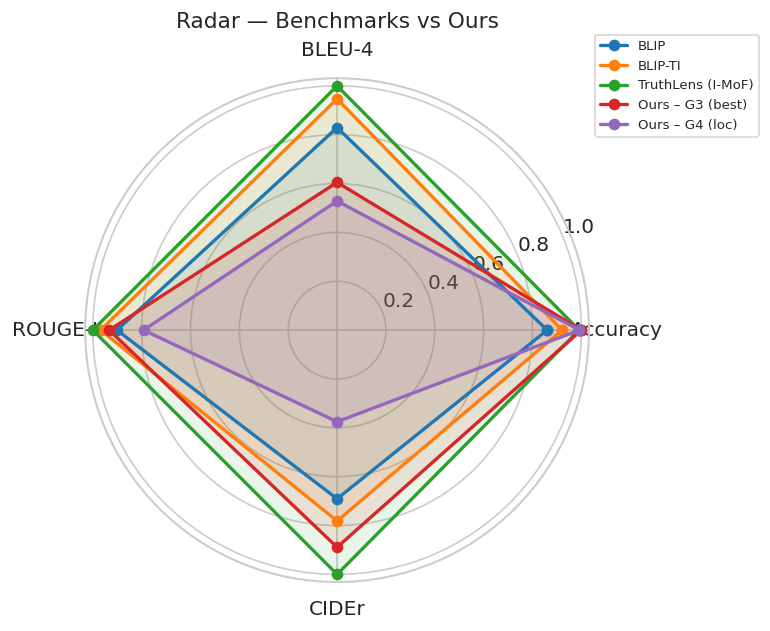

In [19]:
radar_methods = [n for n in BENCHMARK_DETAILS if BENCHMARK_DETAILS[n].get("cider") is not None]
radar_metrics = ["accuracy", "bleu_4", "rouge_l", "cider"]
radar_labels = ["Accuracy", "BLEU-4", "ROUGE-L", "CIDEr"]

max_vals = {}
for m in radar_metrics:
    vals = [BENCHMARK_DETAILS[n].get(m, 0) or 0 for n in radar_methods]
    max_vals[m] = max(vals) if vals else 1

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors_radar = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for i, name in enumerate(radar_methods):
    vals = [(BENCHMARK_DETAILS[name].get(m, 0) or 0) / max_vals[m] for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", label=name, color=colors_radar[i % len(colors_radar)], linewidth=2)
    ax.fill(angles, vals, alpha=0.1, color=colors_radar[i % len(colors_radar)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels)
ax.set_title("Radar — Benchmarks vs Ours", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
param_names = []
param_counts = []
param_accs = []
for name, vals in BENCHMARK_DETAILS.items():
    if vals.get("accuracy") is not None and "trainable_params_num" in vals:
        param_names.append(name)
        param_counts.append(vals["trainable_params_num"])
        param_accs.append(vals["accuracy"])

fig, ax = plt.subplots(figsize=(10, 5))
colors_p = ["#636efa" if "Ours" not in n else "#00cc96" for n in param_names]
ax.scatter(param_counts, param_accs, s=150, c=colors_p, edgecolors="black", zorder=5)
for i, name in enumerate(param_names):
    ax.annotate(name, (param_counts[i], param_accs[i]),
                textcoords="offset points", xytext=(8, 8), fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Trainable Parameters (log scale)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Trainable Parameters — Efficiency Comparison")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## S7. Placeholder: t-SNE do DINOv2 LoRA Classifier

Esta seção visualiza os embeddings (CLS token) do DINOv2 LoRA classifier
projetados em 2D via t-SNE.

**Comparações**:
1. DINOv2 **sem LoRA** (frozen) vs DINOv2 **com LoRA** (treinado em FF++)
2. Colorido por **Real vs Fake** e por **método de manipulação**

### Para gerar os embeddings no servidor:

```bash
python scripts/extract_tsne_embeddings.py \
    --checkpoint outputs/dino_lora_classifier/best.pt \
    --metadata /datasets/deepfake/ddvqa_prepared/test.jsonl \
    --images-dir /datasets/deepfake/ddvqa_prepared/frames \
    --output outputs/analysis/tsne_embeddings.npz
```

O script extrai CLS tokens do DINOv2 com e sem LoRA para o dataset
DD-VQA **test** (deduplica por imagem) e salva tudo em um `.npz`.

In [ ]:
TSNE_PATH = ROOT / "outputs" / "analysis" / "tsne_embeddings.npz"

if TSNE_PATH.exists():
    data = np.load(TSNE_PATH, allow_pickle=True)
    emb_lora = data["embeddings_lora"]
    emb_frozen = data["embeddings_frozen"]
    labels = data["labels"]
    methods = data["methods"]

    from sklearn.manifold import TSNE

    def plot_tsne(embeddings, labels, methods, title_prefix):
        tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
        proj = tsne.fit_transform(embeddings)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        label_colors = {"real": "#2ca02c", "fake": "#d62728"}
        for label in ["real", "fake"]:
            mask = labels == label
            axes[0].scatter(proj[mask, 0], proj[mask, 1], s=8, alpha=0.5,
                           c=label_colors[label], label=label.capitalize())
        axes[0].legend()
        axes[0].set_title(f"{title_prefix} — Real vs Fake")
        axes[0].set_xticks([])
        axes[0].set_yticks([])

        method_colors = plt.cm.tab10(np.linspace(0, 1, len(METHODS_ORDER)))
        for i, method in enumerate(METHODS_ORDER):
            mask = methods == method
            if mask.sum() == 0:
                continue
            axes[1].scatter(proj[mask, 0], proj[mask, 1], s=8, alpha=0.5,
                           c=[method_colors[i]], label=method)
        axes[1].legend(fontsize=8, markerscale=3)
        axes[1].set_title(f"{title_prefix} — Por Método")
        axes[1].set_xticks([])
        axes[1].set_yticks([])

        plt.tight_layout()
        plt.show()

    plot_tsne(emb_frozen, labels, methods, "DINOv2 Frozen (sem LoRA)")
    plot_tsne(emb_lora, labels, methods, "DINOv2 LoRA (treinado em FF++)")
else:
    print(f"Arquivo t-SNE não encontrado: {TSNE_PATH}")
    print("Execute no servidor: python scripts/extract_tsne_embeddings.py")

---
## S8. Placeholder: GradCAM / Attention Maps do DINOv2

Visualização das regiões de atenção do DINOv2 LoRA comparadas com:
- Bounding boxes preditas pelo LLM (G4)
- Justificativa textual gerada

### Para gerar os mapas de atenção no servidor:

```bash
python scripts/extract_attention_maps.py \
    --checkpoint outputs/dino_lora_classifier/best.pt \
    --images-dir /datasets/deepfake/ddvqa_prepared/frames \
    --predictions outputs/ablation/g4_lora_loc/evaluation/best_test/predictions.jsonl \
    --output outputs/analysis/attention_maps.npz \
    --n-samples 50
```

O script extrai attention maps da última camada (CLS→patches) do DINOv2
para imagens selecionadas.

In [ ]:
ATTN_PATH = ROOT / "outputs" / "analysis" / "attention_maps.npz"

if ATTN_PATH.exists():
    data = np.load(ATTN_PATH, allow_pickle=True)
    images_arr = data["images"]
    attn_maps = data["attn_maps"]
    attn_labels = data["labels"]
    attn_filenames = data["filenames"]
    attn_predictions = data.get("predictions", None)
    attn_references = data.get("references", None)

    n_show = min(8, len(images_arr))
    fig, axes = plt.subplots(n_show, 3, figsize=(15, 5 * n_show))
    if n_show == 1:
        axes = axes[np.newaxis, :]

    for i in range(n_show):
        img = images_arr[i]
        attn = attn_maps[i]
        fname = attn_filenames[i] if isinstance(attn_filenames[i], str) else str(attn_filenames[i])
        label = attn_labels[i] if isinstance(attn_labels[i], str) else str(attn_labels[i])

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{fname}\n({label})", fontsize=9)
        axes[i, 0].axis("off")

        n_patches_side = int(np.sqrt(attn.shape[0]))
        attn_2d = attn.reshape(n_patches_side, n_patches_side)
        attn_resized = np.array(Image.fromarray(attn_2d).resize(
            (img.shape[1], img.shape[0]), resample=Image.BILINEAR
        ))
        axes[i, 1].imshow(img)
        axes[i, 1].imshow(attn_resized, cmap="jet", alpha=0.5)
        axes[i, 1].set_title("DINOv2 Attention", fontsize=9)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(img)
        if attn_predictions is not None and i < len(attn_predictions):
            pred_text = attn_predictions[i] if isinstance(attn_predictions[i], str) else str(attn_predictions[i])
            pred_boxes = parse_loc_tokens(pred_text)
            h_img, w_img = img.shape[:2]
            for (y1, x1, y2, x2) in pred_boxes:
                rect = mpatches.Rectangle(
                    (x1 / 1000 * w_img, y1 / 1000 * h_img),
                    (x2 - x1) / 1000 * w_img,
                    (y2 - y1) / 1000 * h_img,
                    linewidth=2, edgecolor="red", facecolor="none", linestyle="--",
                )
                axes[i, 2].add_patch(rect)
            axes[i, 2].set_title("LLM Pred Bboxes", fontsize=9)
        axes[i, 2].axis("off")

    fig.suptitle("DINOv2 Attention vs LLM Predictions", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"Arquivo de attention maps não encontrado: {ATTN_PATH}")
    print("Execute no servidor: python scripts/extract_attention_maps.py")

---
## S9. Coerência: Veredito × Justificativa

In [ ]:
def analyze_coherence(df: pd.DataFrame, exp_name: str):
    """Analyze verdict coherence: TP/FP/TN/FN buckets with textual examples."""
    df = df.copy()
    conditions = [
        (df["true_label"] == "fake") & (df["pred_label"] == "fake"),
        (df["true_label"] == "fake") & (df["pred_label"] == "real"),
        (df["true_label"] == "real") & (df["pred_label"] == "real"),
        (df["true_label"] == "real") & (df["pred_label"] == "fake"),
    ]
    bucket_names = ["TP (Fake→Fake)", "FN (Fake→Real)", "TN (Real→Real)", "FP (Real→Fake)"]
    df["bucket"] = np.select(conditions, bucket_names, default="Unknown")

    print(f"=== Coerência — {exp_name} ===")
    counts = df["bucket"].value_counts()
    total = len(df)
    for bucket in bucket_names:
        n = counts.get(bucket, 0)
        print(f"  {bucket}: {n} ({n/total:.1%})")

    if "method" in df.columns:
        print("\n--- Crosstab: Bucket × Método ---")
        ct = pd.crosstab(df["bucket"], df["method"])
        ct = ct.reindex(index=bucket_names, columns=METHODS_ORDER, fill_value=0)
        display(ct)

    print("\n--- Exemplos por bucket ---")
    for bucket in bucket_names:
        sub = df[df["bucket"] == bucket]
        if len(sub) == 0:
            continue
        sample = sub.sample(n=min(2, len(sub)), random_state=42)
        print(f"\n[{bucket}]")
        for _, row in sample.iterrows():
            method_str = row.get("method", "?")
            gen_short = textwrap.shorten(row["generated"], width=150, placeholder="...")
            print(f"  ({method_str}) {row['image']} | Q: {row['question']}")
            print(f"    Gen: {gen_short}")
    print()


for exp_name in ["G3 – DINOv2 LoRA", "G4 – LoRA + Loc"]:
    if exp_name in preds_all:
        analyze_coherence(preds_all[exp_name], exp_name)

---
## S10. Exportação de Resumos (CSV)

In [ ]:
EXPORT_DIR = ROOT / "outputs" / "analysis"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

df_summary.to_csv(EXPORT_DIR / "ablation_summary.csv")
print(f"Salvo: {EXPORT_DIR / 'ablation_summary.csv'}")

if per_method_dfs:
    all_methods = []
    for exp_name, df in per_method_dfs.items():
        tmp = df.copy()
        tmp["Experiment"] = exp_name
        all_methods.append(tmp.reset_index())
    df_methods_all = pd.concat(all_methods, ignore_index=True)
    df_methods_all.to_csv(EXPORT_DIR / "per_method_summary.csv", index=False)
    print(f"Salvo: {EXPORT_DIR / 'per_method_summary.csv'}")

df_bench.to_csv(EXPORT_DIR / "benchmark_comparison.csv")
print(f"Salvo: {EXPORT_DIR / 'benchmark_comparison.csv'}")

print(f"\nTodos os CSVs exportados para {EXPORT_DIR}")